In [38]:
import re
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Honor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Honor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Honor\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Honor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
df = pd.read_csv('spam_2_1.csv')

In [40]:
print(f"Размер датасета: {df.shape}")

Размер датасета: (5572, 5)


In [41]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [42]:
df = df[['v2', 'v1']]

df = df.rename(columns={
    'v1': 'label',
    'v2': 'text'
})

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

In [43]:
df.head()

,text,label,label_num
0,"Go until jurong point, crazy.. Available only ...",ham,0
1,Ok lar... Joking wif u oni...,ham,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,1
3,U dun say so early hor... U c already then say...,ham,0
4,"Nah I don't think he goes to usf, he lives aro...",ham,0


In [44]:
def get_punct_percent(text):
    count = 0
    for char in text:
        if char in string.punctuation:
            count += 1
    return count / len(text) * 100

def get_caps_ratio(text):    
    count = 0
    for char in text:
        if char.isupper():
            count += 1
    return count / len(text) * 100

def get_digit_percent(text):
    count = 0
    for char in text:
        if char.isdigit():
            count += 1
    return count / len(text) * 100

In [45]:
df['length'] = df['text'].apply(len)
df['punct_percent'] = df['text'].apply(get_punct_percent)
df['caps_ratio'] = df['text'].apply(get_caps_ratio)
df['digit_percent'] = df['text'].apply(get_digit_percent)

In [46]:
df.head()

,text,label,label_num,length,punct_percent,caps_ratio,digit_percent
0,"Go until jurong point, crazy.. Available only ...",ham,0,111,8.108108,2.702703,0.000000
1,Ok lar... Joking wif u oni...,ham,0,29,20.689655,6.896552,0.000000
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,1,155,3.870968,6.451613,16.129032
3,U dun say so early hor... U c already then say...,ham,0,49,12.244898,4.081633,0.000000
4,"Nah I don't think he goes to usf, he lives aro...",ham,0,61,3.278689,3.278689,0.000000


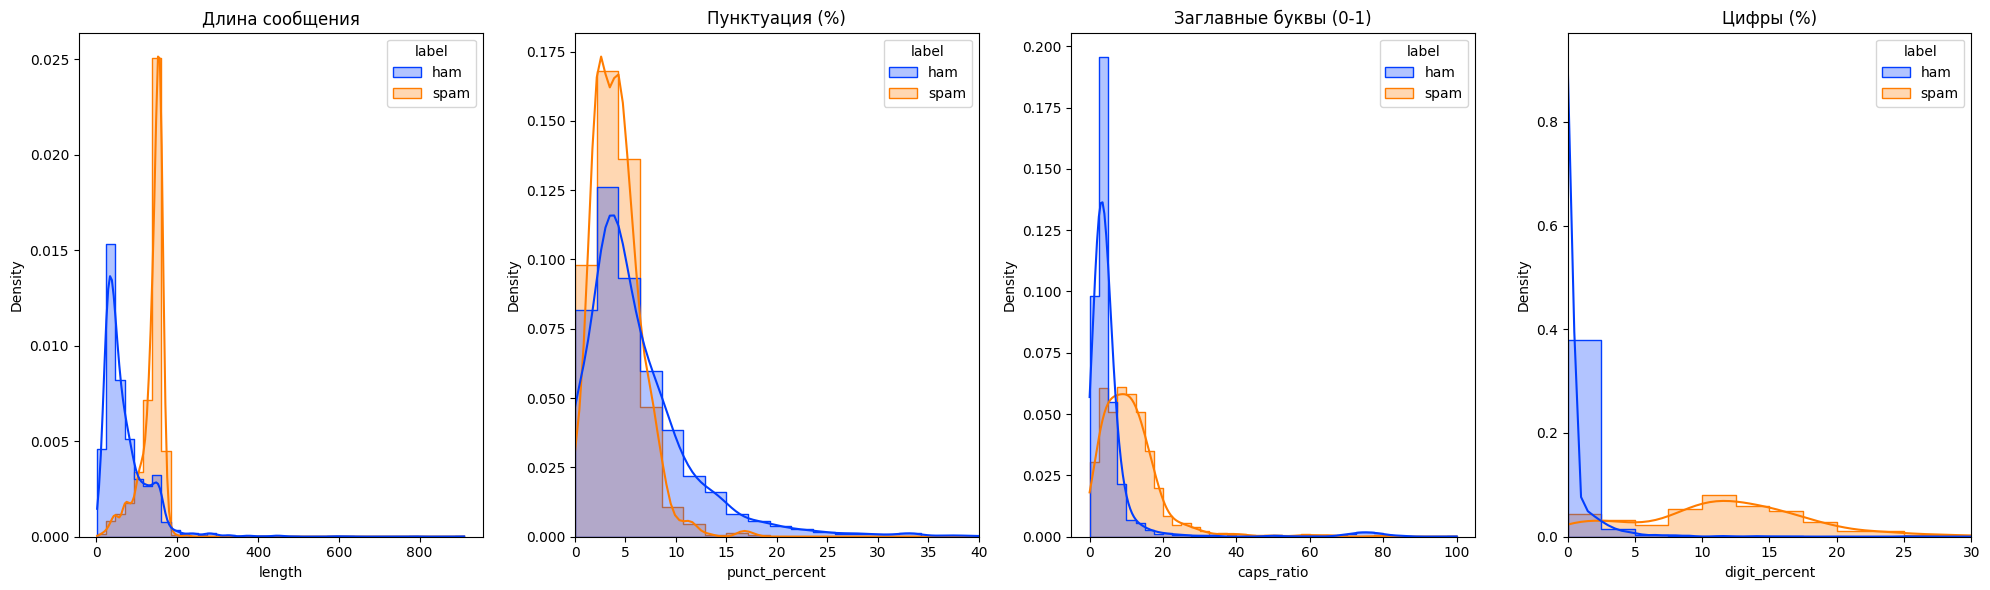

In [47]:
plt.figure(figsize=(20, 6))

kwargs = dict(bins=40, kde=True, stat='density', common_norm=False, palette='bright', element="step", alpha=0.3)

plt.subplot(1, 4, 1)
sns.histplot(data=df, x='length', hue='label', **kwargs)
plt.title('Длина сообщения')

plt.subplot(1, 4, 2)
sns.histplot(data=df, x='punct_percent', hue='label', **kwargs)
plt.xlim(0, 40)
plt.title('Пунктуация (%)')

plt.subplot(1, 4, 3)
sns.histplot(data=df, x='caps_ratio', hue='label', **kwargs)
plt.title('Заглавные буквы (0-1)')

plt.subplot(1, 4, 4)
sns.histplot(data=df, x='digit_percent', hue='label', **kwargs)
plt.xlim(0, 30)
plt.title('Цифры (%)')

plt.tight_layout()
plt.show()

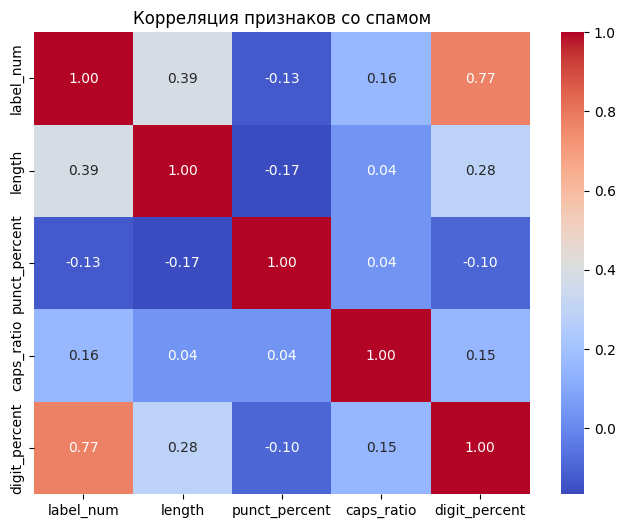

In [48]:
numeric_cols = df[['label_num', 'length', 'punct_percent', 'caps_ratio', 'digit_percent']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция признаков со спамом')
plt.show()

In [49]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [50]:
def clean_text(text):
    
    text = text.lower()
    
    text_no_punct = ""
    for char in text:
        if char not in string.punctuation:
            text_no_punct += char

    tokens = text_no_punct.split()
    
    clean_tokens = []
    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            clean_tokens.append(lemma) 
    
    return " ".join(clean_tokens)

In [51]:
df['clean_text'] = df['text'].apply(clean_text)

In [52]:
print("ИСХОДНЫЙ:", df['text'].iloc[0])
print("ОЧИЩЕННЫЙ:", df['clean_text'].iloc[0]) 

ИСХОДНЫЙ: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
ОЧИЩЕННЫЙ: go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [53]:
X = df['clean_text']
y = df['label_num']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
tfidf_vect = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_test_tfidf = tfidf_vect.transform(X_test)

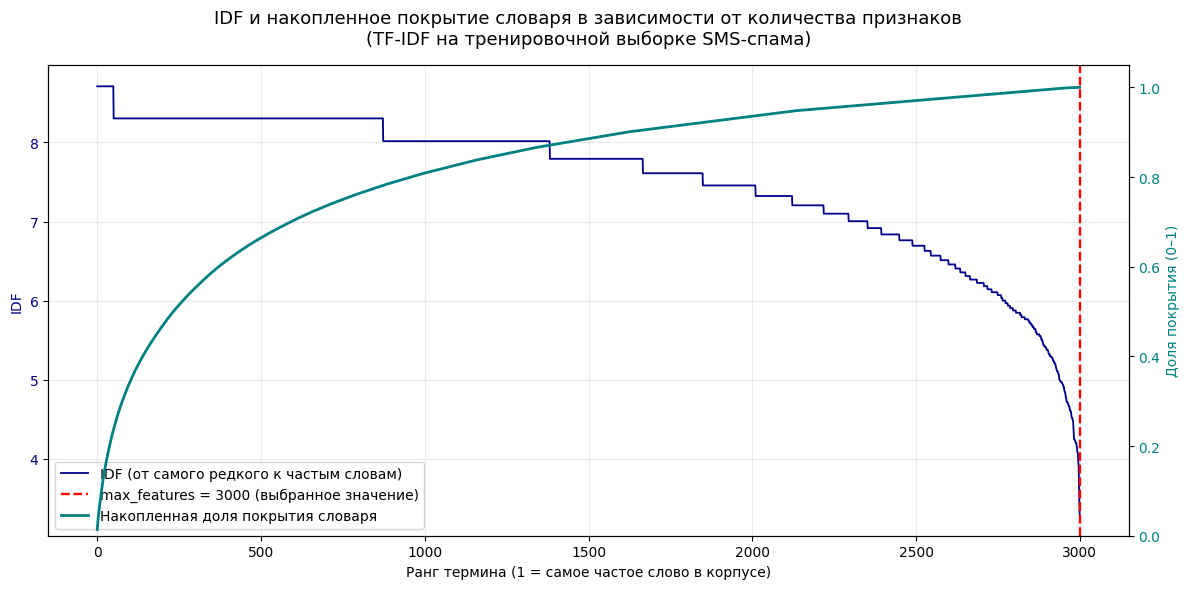

In [56]:

idf = tfidf_vect.idf_                        
sorted_idf = np.sort(idf)[::-1]                


X_train_dense = X_train_tfidf.toarray()        
doc_freq = (X_train_dense > 0).sum(axis=0)     
sorted_freq = np.sort(doc_freq)[::-1]
cumulative_coverage = np.cumsum(sorted_freq) / np.sum(doc_freq)

fig, ax1 = plt.subplots(figsize=(12, 6))


ax1.plot(sorted_idf, color='darkblue', linewidth=1.3, label='IDF (от самого редкого к частым словам)')
ax1.set_xlabel('Ранг термина (1 = самое частое слово в корпусе)')
ax1.set_ylabel('IDF', color='darkblue')
ax1.tick_params(axis='y', labelcolor='darkblue')
ax1.grid(True, alpha=0.25)


ax2 = ax1.twinx()
ax2.plot(cumulative_coverage, color='teal', linewidth=2.0, label='Накопленная доля покрытия словаря')
ax2.set_ylabel('Доля покрытия (0–1)', color='teal')
ax2.tick_params(axis='y', labelcolor='teal')
ax2.set_ylim(0, 1.05)

ax1.axvline(x=3000,color='red', linestyle='--', linewidth=1.7, label='max_features = 3000 (выбранное значение)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

plt.title('IDF и накопленное покрытие словаря в зависимости от количества признаков\n'
          '(TF-IDF на тренировочной выборке SMS-спама)', 
          fontsize=13, pad=15)

plt.tight_layout()
plt.show()

In [57]:
print(f"Размерность матрицы Train: {X_train_tfidf.shape}")
print(f"Размерность матрицы Test:  {X_test_tfidf.shape}")

Размерность матрицы Train: (4457, 3000)
Размерность матрицы Test:  (1115, 3000)


In [58]:
dt_model = DecisionTreeClassifier(
    max_depth=35,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)
dt_model.fit(X_train_tfidf, y_train)
y_pred_dt = dt_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_dt, digits=4))

              precision    recall  f1-score   support

           0     0.9754    0.9834    0.9794       966
           1     0.8865    0.8389    0.8621       149

    accuracy                         0.9641      1115
   macro avg     0.9309    0.9112    0.9207      1115
weighted avg     0.9635    0.9641    0.9637      1115



In [59]:
MAX_WORDS = 3000
MAX_LEN = 150

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

In [60]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

In [61]:
sequences_train = tokenizer.texts_to_sequences(X_train_raw)
sequences_test = tokenizer.texts_to_sequences(X_test_raw)

In [62]:
X_train_seq = pad_sequences(sequences_train, maxlen=MAX_LEN, padding='pre', truncating='post')
X_test_seq = pad_sequences(sequences_test, maxlen=MAX_LEN, padding='pre', truncating='post')

In [63]:
print(f"Пример текста:\n{X_train_raw.iloc[0]}")
print(f"\nПример последовательности:\n{X_train_seq[0]}")
print(f"\nРазмерность входа для сети: {X_train_seq.shape}")

Пример текста:
Going on nothing great.bye

Пример последовательности:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0   73   19  327  119 1269]

Размерность входа для сети: (4457, 150)


In [64]:
model = Sequential()
model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN))
model.add(SpatialDropout1D(0.4))
model.add(LSTM(32, dropout=0.4, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')
model.summary()

C:\Users\Honor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
early_stop = EarlyStopping(
    monitor='val_loss',      
    patience=2,              
    restore_best_weights=True  
)

history = model.fit(
    X_train_seq, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0291 - val_loss: 0.0433
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0177 - val_loss: 0.0445
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0116 - val_loss: 0.0398
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0166 - val_loss: 0.0419
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0088 - val_loss: 0.0444


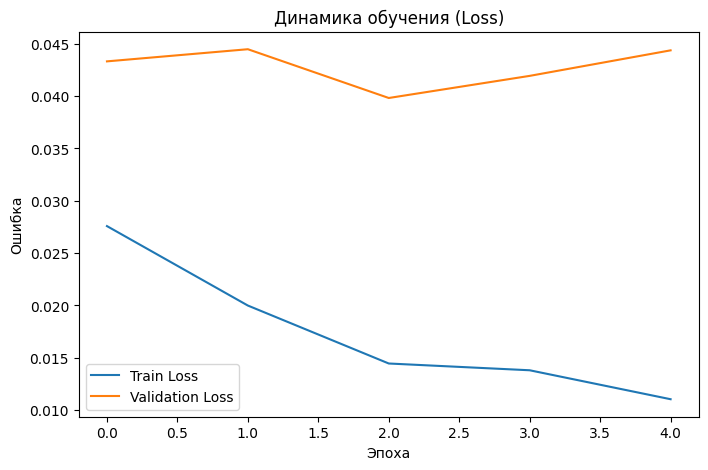

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Динамика обучения (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.show()

In [70]:
y_pred_dl_prob = model.predict(X_test_seq)
y_pred_dl = (y_pred_dl_prob > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [71]:
print(classification_report(y_test, y_pred_dl))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115

